In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [3]:
# Load the Data
data = pd.read_csv("smartcart_customers.csv")
data.head()
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# DATA PREPROCESSING

# 1. Filling the null values

In [4]:
data["Income"] = data["Income"].fillna(data["Income"].median())


# FEATURE ENGINEERING

In [39]:
# Change the age into numarical value 
data["age"] = 2026 - data["Year_Birth"]
# chnaging the Date of joinning of the customer into tenure of the customer
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True) # because normally in pandas the date formate is month, day, year
reference_date = data["Dt_Customer"].max()
data["Teneur"] = (reference_date - data["Dt_Customer"]).dt.days

# we add different features into one
# first we make one column for spending
data["spending"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]
data["tatal_kids"] = data["Kidhome"] + data["Teenhome"]

# Education and martial status need to convert into maximum 3 or 2 categories
data["Living_with"] = data["Marital_Status"].replace({ "Married": "Partner", "Together": "Partner", "Single": "Alone",
                                                          "Divorced":"Alone", "Widow":"Alone", "Alone": "Alone", 
                                                          "Absurd":"Alone", "YOLO":"Alone"})
data["Education"] = data["Education"].replace({"Graduation":"Graduate", "PhD" : "Post_graduate", "Master":"Post_graduate",
                                               "2n Cycle": "Under_graduate", "Basic":"Under_graduate"})
# now removing the unnecessary columns
col_rem = ["ID", "Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
data_cleaned = data.drop(columns = col_rem)                    

# Look for the Outliers

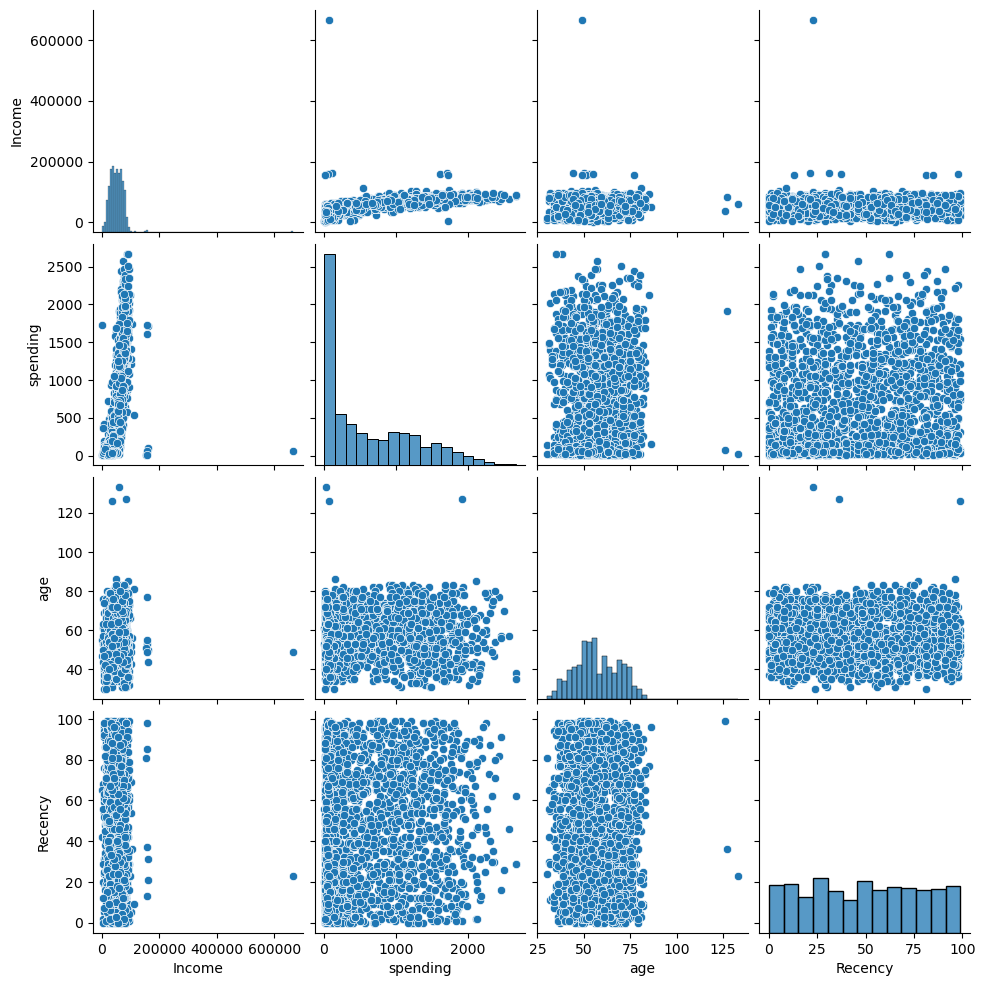

In [48]:
col = ["Income","spending","age", "Recency"]
# Relative plots of some features -- pair plots
sns.pairplot(data_cleaned[col])
data_cleaned = data_cleaned[ (data_cleaned["age"] <90) ]
data_cleaned = data_cleaned[ (data_cleaned["Income"] < 600000) ]

# Drawing the Heatmap

<Axes: >

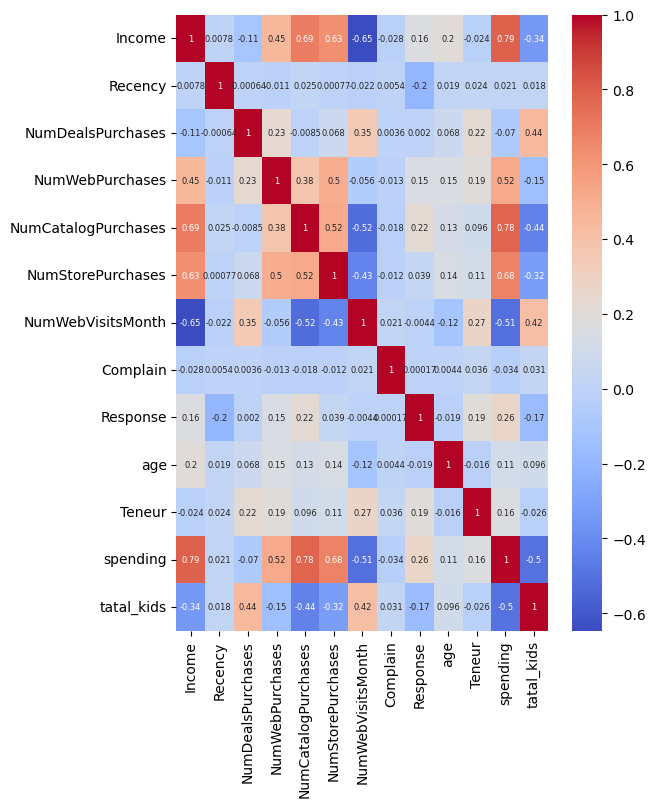

In [51]:
crr = data_cleaned.corr(numeric_only=True)
plt.figure(figsize=(6,8))
sns.heatmap(
    crr,
    annot=True,
    annot_kws={"size":6},
    cmap = "coolwarm")

In [40]:
data.head()
data_cleaned.head()
data_cleaned.shape

(2240, 15)

In [68]:
data.columns
data["Marital_Status"].value_counts()
data["Education"].value_counts()
data.columns

Education
Graduate          1127
Post_graduate      856
Under_graduate     257
Name: count, dtype: int64

In [53]:
data_cleaned.head()


,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Teneur,spending,tatal_kids,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1705,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,28,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,797,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,56,1,Partner
4,Post_graduate,58293.0,94,5,5,3,6,5,0,0,45,161,449,1,Partner


# Encoding and Scaling

In [60]:
oho = OneHotEncoder()
col_oho = ["Education", "Living_with"]
enc_col = oho.fit_transform(data_cleaned[col_oho])
enc_df = pd.DataFrame(enc_col.toarray(), columns= oho.get_feature_names_out(col_oho), index = data_cleaned.index)
data_encoded = pd.concat([data_cleaned.drop(columns=col_oho), enc_df], axis = 1)
data_encoded.head()

x = data_encoded
sc = StandardScaler()
x_scaled = sc.fit_transform(x)
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualization of our data


array([0.23185128, 0.11385369])

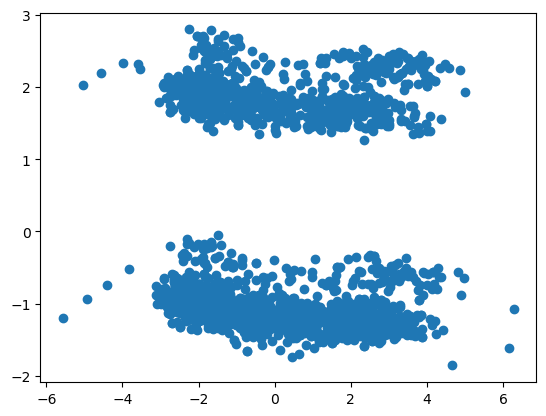

In [64]:
# in 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(x_scaled)
pca_data
plt.scatter(pca_data[:,0], pca_data[:,1])
pca.explained_variance_ratio_

array([0.23185128, 0.11385369, 0.10403978])

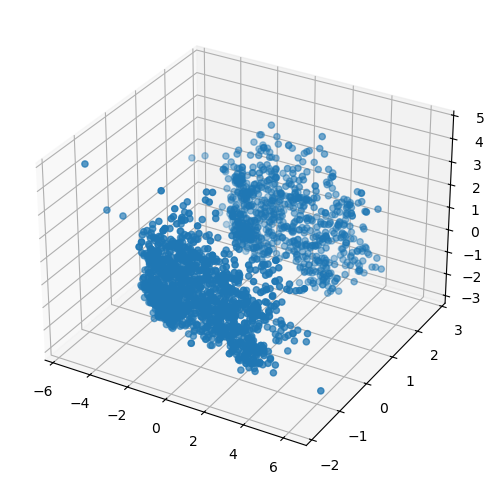

In [67]:
# In 3D
pca = PCA(n_components=3)
pca_data = pca.fit_transform(x_scaled)
pca_data
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2])
pca.explained_variance_ratio_

# Analyzing the K value

# 1. Elbow Method

In [74]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)
knee = KneeLocator(range(1,10), wcss, curve = "convex", direction = "decreasing")
print("The optimum value of k is", knee.elbow)

The optimum value of k is 4


Text(0.5, 1.0, 'K Vs WCSS')

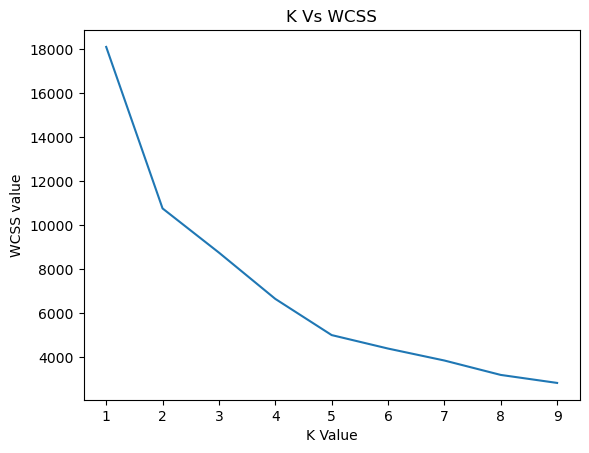

In [77]:
# plot in the graph
sns.lineplot(x = range(1,10), y = wcss, markers="O")
plt.xlabel("K Value")
plt.ylabel("WCSS value")
plt.title("K Vs WCSS")


# 2. from silhoutte score 

Text(0.5, 1.0, 'K Vs score')

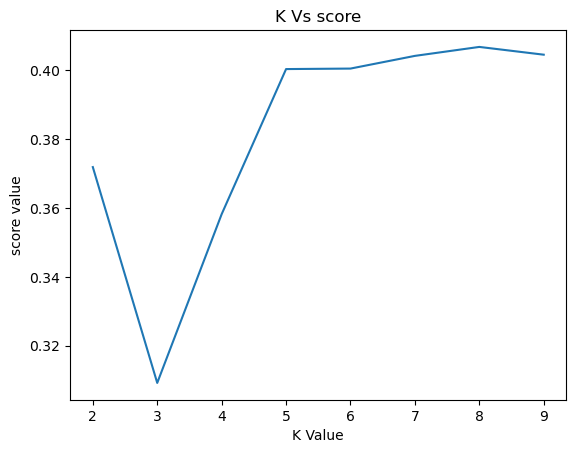

In [83]:
from sklearn.metrics import silhouette_score
score = []
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    lables = kmeans.fit_predict(pca_data)
    scores= silhouette_score(pca_data, lables)
    score.append(scores)
sns.lineplot(x = range(2,10), y = score, markers="O")
plt.xlabel("K Value")
plt.ylabel("score value")
plt.title("K Vs score")

# Clustering

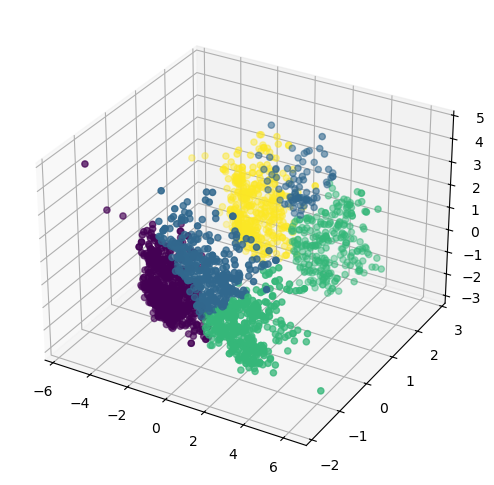

In [84]:
# KMEANS

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(pca_data)
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2], c = labels)


# With Aggloramative Clustering


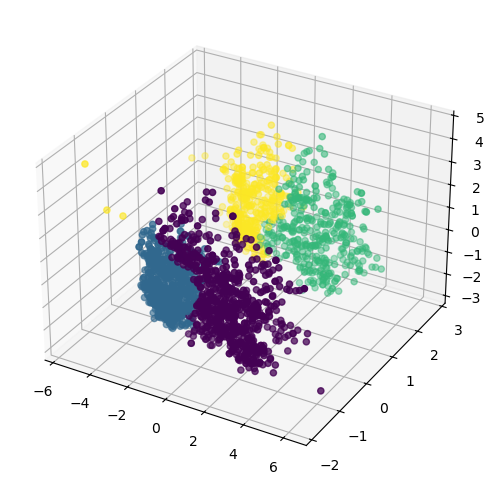

In [87]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(pca_data)
fig = plt.figure(figsize=(6,8))
ax = fig.add_subplot(111, projection= "3d")
ax.scatter(pca_data[:,0], pca_data[:,1], pca_data[:,2], c = labels_agg)


# as shown in the figure Agglomerative clustering perfrom better, so we continue with that 

# CHARACTARIZATION

<Axes: xlabel='clusters', ylabel='count'>

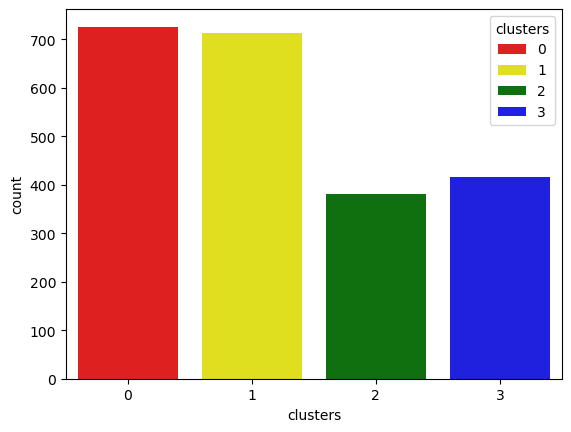

In [99]:
x["clusters"] = labels_agg
x.head()
pal = ["red", "yellow", "Green", "blue"]
sns.countplot(x=x["clusters"], palette= pal, hue=x["clusters"])

<Axes: xlabel='spending', ylabel='Income'>

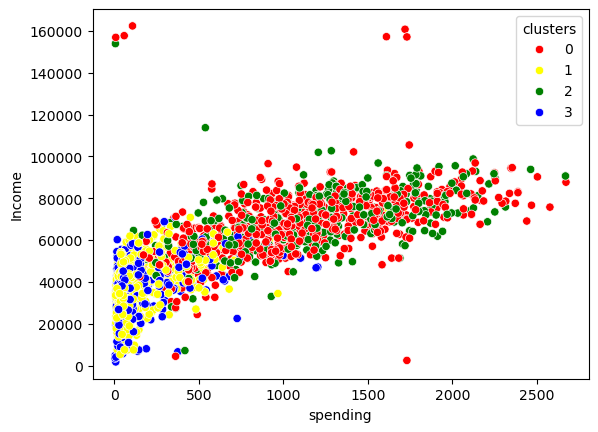

In [100]:
# To get the income and spending values
sns.scatterplot(x = x["spending"], y = x["Income"], hue= x["clusters"], palette=pal)

In [94]:
data_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Teneur,spending,tatal_kids,Living_with,clusters
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1705,0,Alone,2
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,28,2,Alone,3
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,797,0,Partner,0
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,56,1,Partner,1
4,Post_graduate,58293.0,94,5,5,3,6,5,0,0,45,161,449,1,Partner,1


# Cluster summary

In [101]:
cluster_summary = x.groupby("clusters").mean()
print(cluster_summary)

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Teneur,spending,tatal_kids,Education_Graduate,Education_Post_graduate,Education_Under_graduate,Living_with_Alone,Living_with_Partner
clusters,,,,,,,,,,,,,,,,,,
0,67864.764463,48.498623,2.466942,5.681818,4.618457,8.118457,4.118457,0.006887,0.150138,59.637741,368.314050,1102.732782,0.692837,0.471074,0.464187,0.064738,0.000000,1.000000
1,35793.570827,49.553997,2.248247,2.476858,0.645161,3.478261,6.493689,0.011220,0.068724,54.492286,337.159888,138.535764,1.255259,0.527349,0.297335,0.175316,0.000000,1.000000
2,69204.568421,51.189474,1.884211,5.676316,4.760526,8.192105,3.855263,0.005263,0.297368,58.813158,374.910526,1178.736842,0.497368,0.573684,0.360526,0.065789,1.000000,0.000000
3,36157.491607,47.553957,2.616307,2.618705,0.798561,3.529976,6.733813,0.011990,0.151079,55.589928,337.601918,163.688249,1.292566,0.455635,0.405276,0.139089,0.992806,0.007194
